### Open All Powder Patch Data from Mesonet, downloaded from 2010 to 1 June 2025

Notebook contents 
* Taking a look at downloading all the data possible from Powder Patch, from "2002" which is really 2010 starting, to 1 June 2025
* Let's see what it looks like, specifically snow depth and see if significiant data is missing..

created by Cassie Lumbrazo\
last updated: June 2025\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages }
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

In [2]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

In [3]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

## Data Source 
So, the API request was not working for Powder Patch. I could only identify the Juneau Airport from that API. Rather, I've downloaded some test data from Mesonet (https://mesonet2.agron.iastate.edu/request/dcp/fe.phtml?network=AK_DCP)

[`PPSA2`] POWDER PATCH STATION (20..)

There are a few stations identifed on Douglas Island, so I think I'll have to download data from each one and put them together to create a complete dataset. 

For now, we can open the one from `PPSA2` to see what variables are in there.

In [8]:
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/PowderPatch_everything_until_1June2025.txt'

# open
# df = pd.read_csv(filename, skiprows=1, sep='\t', parse_dates=True, index_col='datetime')
df = pd.read_csv(filename, sep = ",")
df

,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
0,PPSA2,2010-12-15 22:00:00,NaN,NaN,0.0,35.0,NaN,18.0,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,80.20,NaN
1,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,55.0,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.00,NaN
2,PPSA2,2011-05-21 03:45:00,NaN,NaN,0.0,90.0,NaN,50.3,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,73.79,NaN
3,PPSA2,2011-05-21 04:15:00,NaN,NaN,0.0,90.0,NaN,45.7,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,84.80,NaN
4,PPSA2,2011-05-21 04:45:00,NaN,NaN,0.0,90.0,NaN,44.5,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,87.10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53308,PPSA2,2025-05-31 20:00:00,NaN,87.60,NaN,NaN,16.48,NaN,39.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.0
53309,PPSA2,2025-05-31 21:00:00,NaN,87.60,NaN,NaN,16.07,NaN,40.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.2
53310,PPSA2,2025-05-31 22:00:00,NaN,87.60,NaN,NaN,16.76,NaN,40.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.1
53311,PPSA2,2025-05-31 23:00:00,NaN,87.64,NaN,NaN,15.96,NaN,40.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91.5


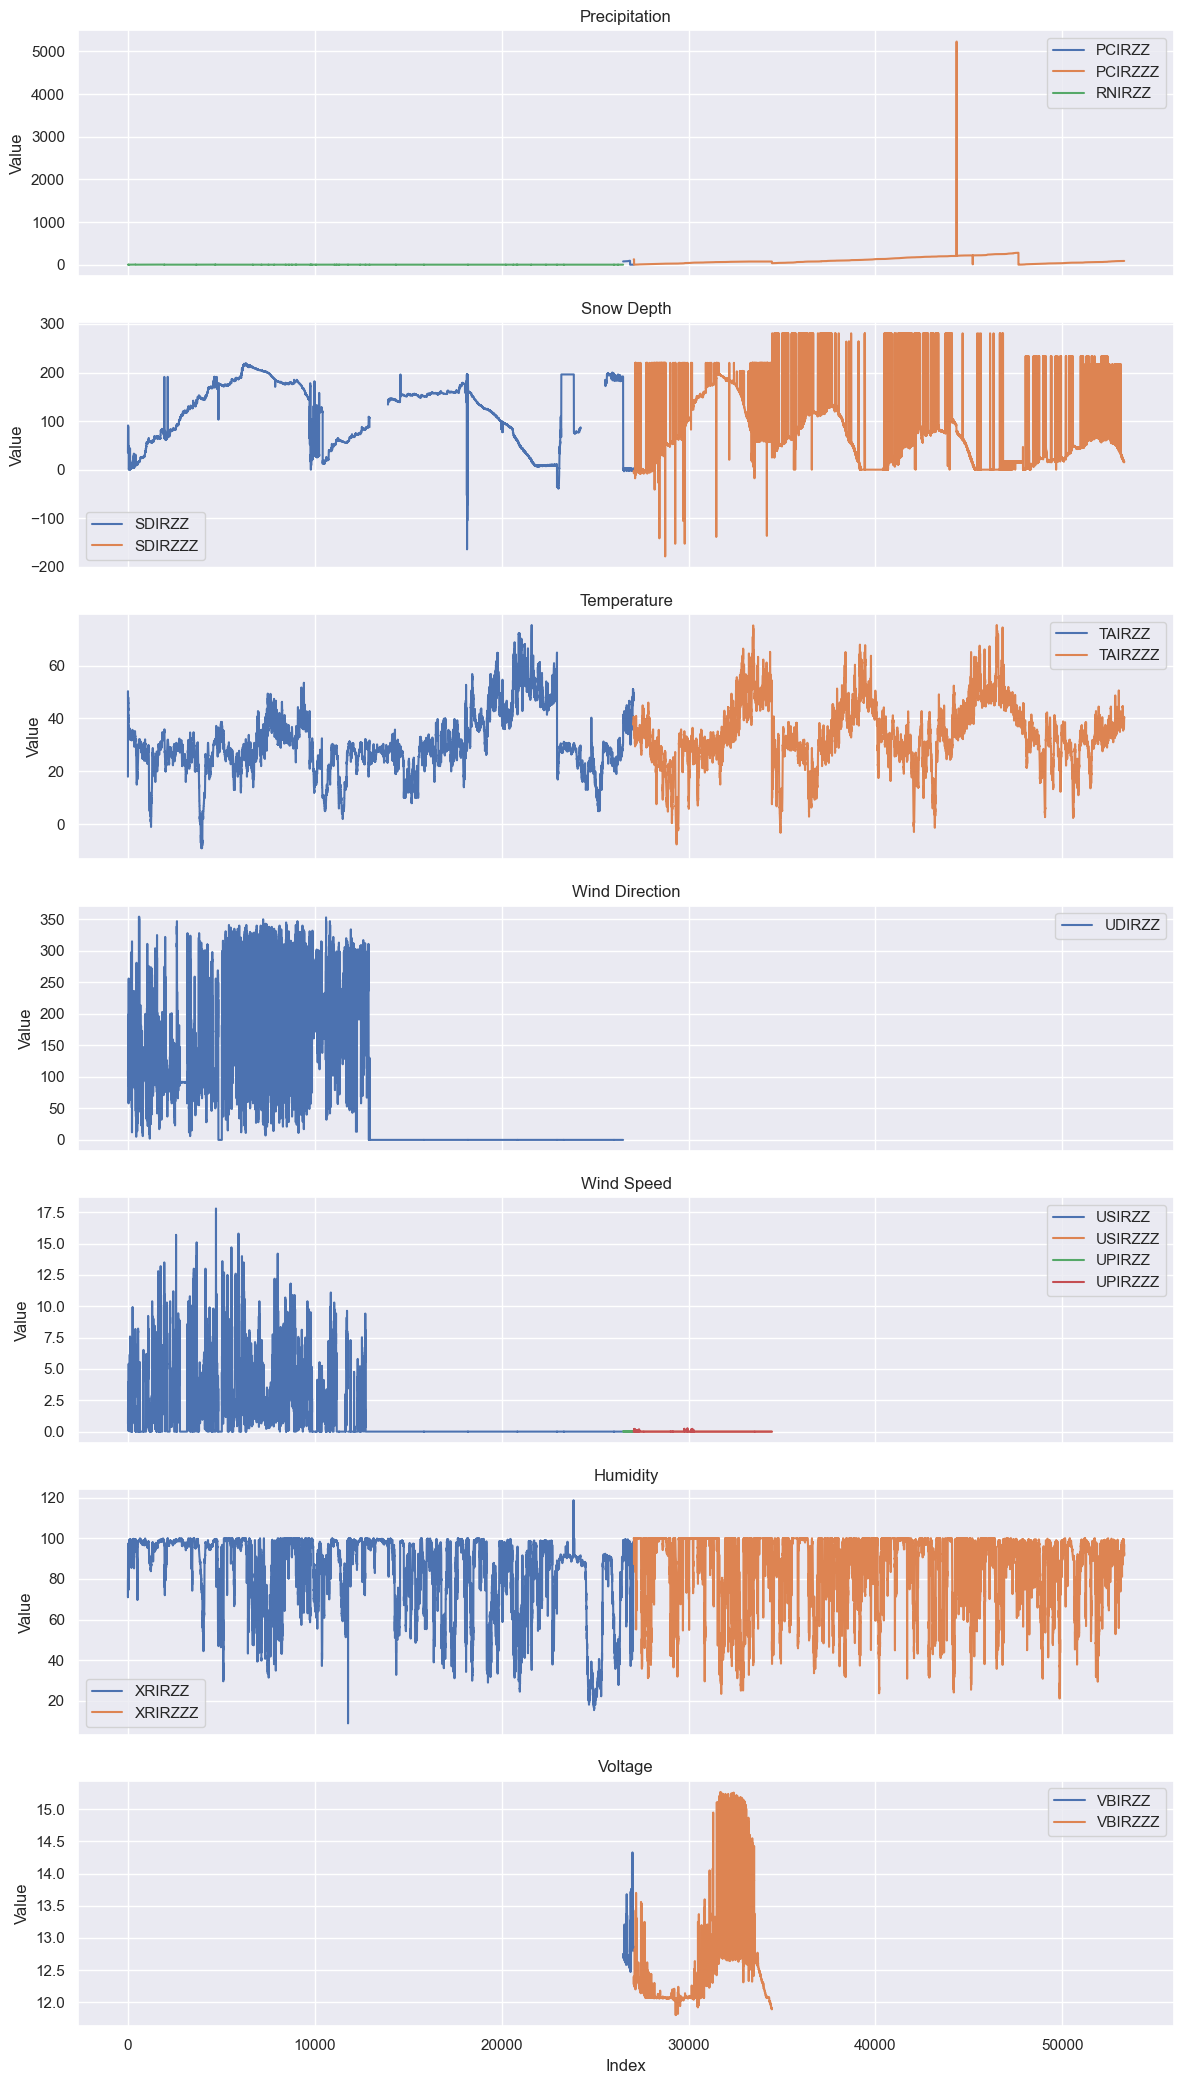

In [9]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df.columns:
            df[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')
plt.tight_layout()
plt.show()

In [10]:
# make utc_valid a datetime and index the df by it 
df['datetime'] = pd.to_datetime(df['utc_valid'])
df = df.set_index('datetime')
df.head()

,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
datetime,,,,,,,,,,,,,,,,,,,
2010-12-15 22:00:00,PPSA2,2010-12-15 22:00:00,NaN,NaN,0.0,35.0,NaN,18.0,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,80.20,NaN
2011-01-09 04:15:00,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,55.0,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.00,NaN
2011-05-21 03:45:00,PPSA2,2011-05-21 03:45:00,NaN,NaN,0.0,90.0,NaN,50.3,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,73.79,NaN
2011-05-21 04:15:00,PPSA2,2011-05-21 04:15:00,NaN,NaN,0.0,90.0,NaN,45.7,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,84.80,NaN
2011-05-21 04:45:00,PPSA2,2011-05-21 04:45:00,NaN,NaN,0.0,90.0,NaN,44.5,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,87.10,NaN


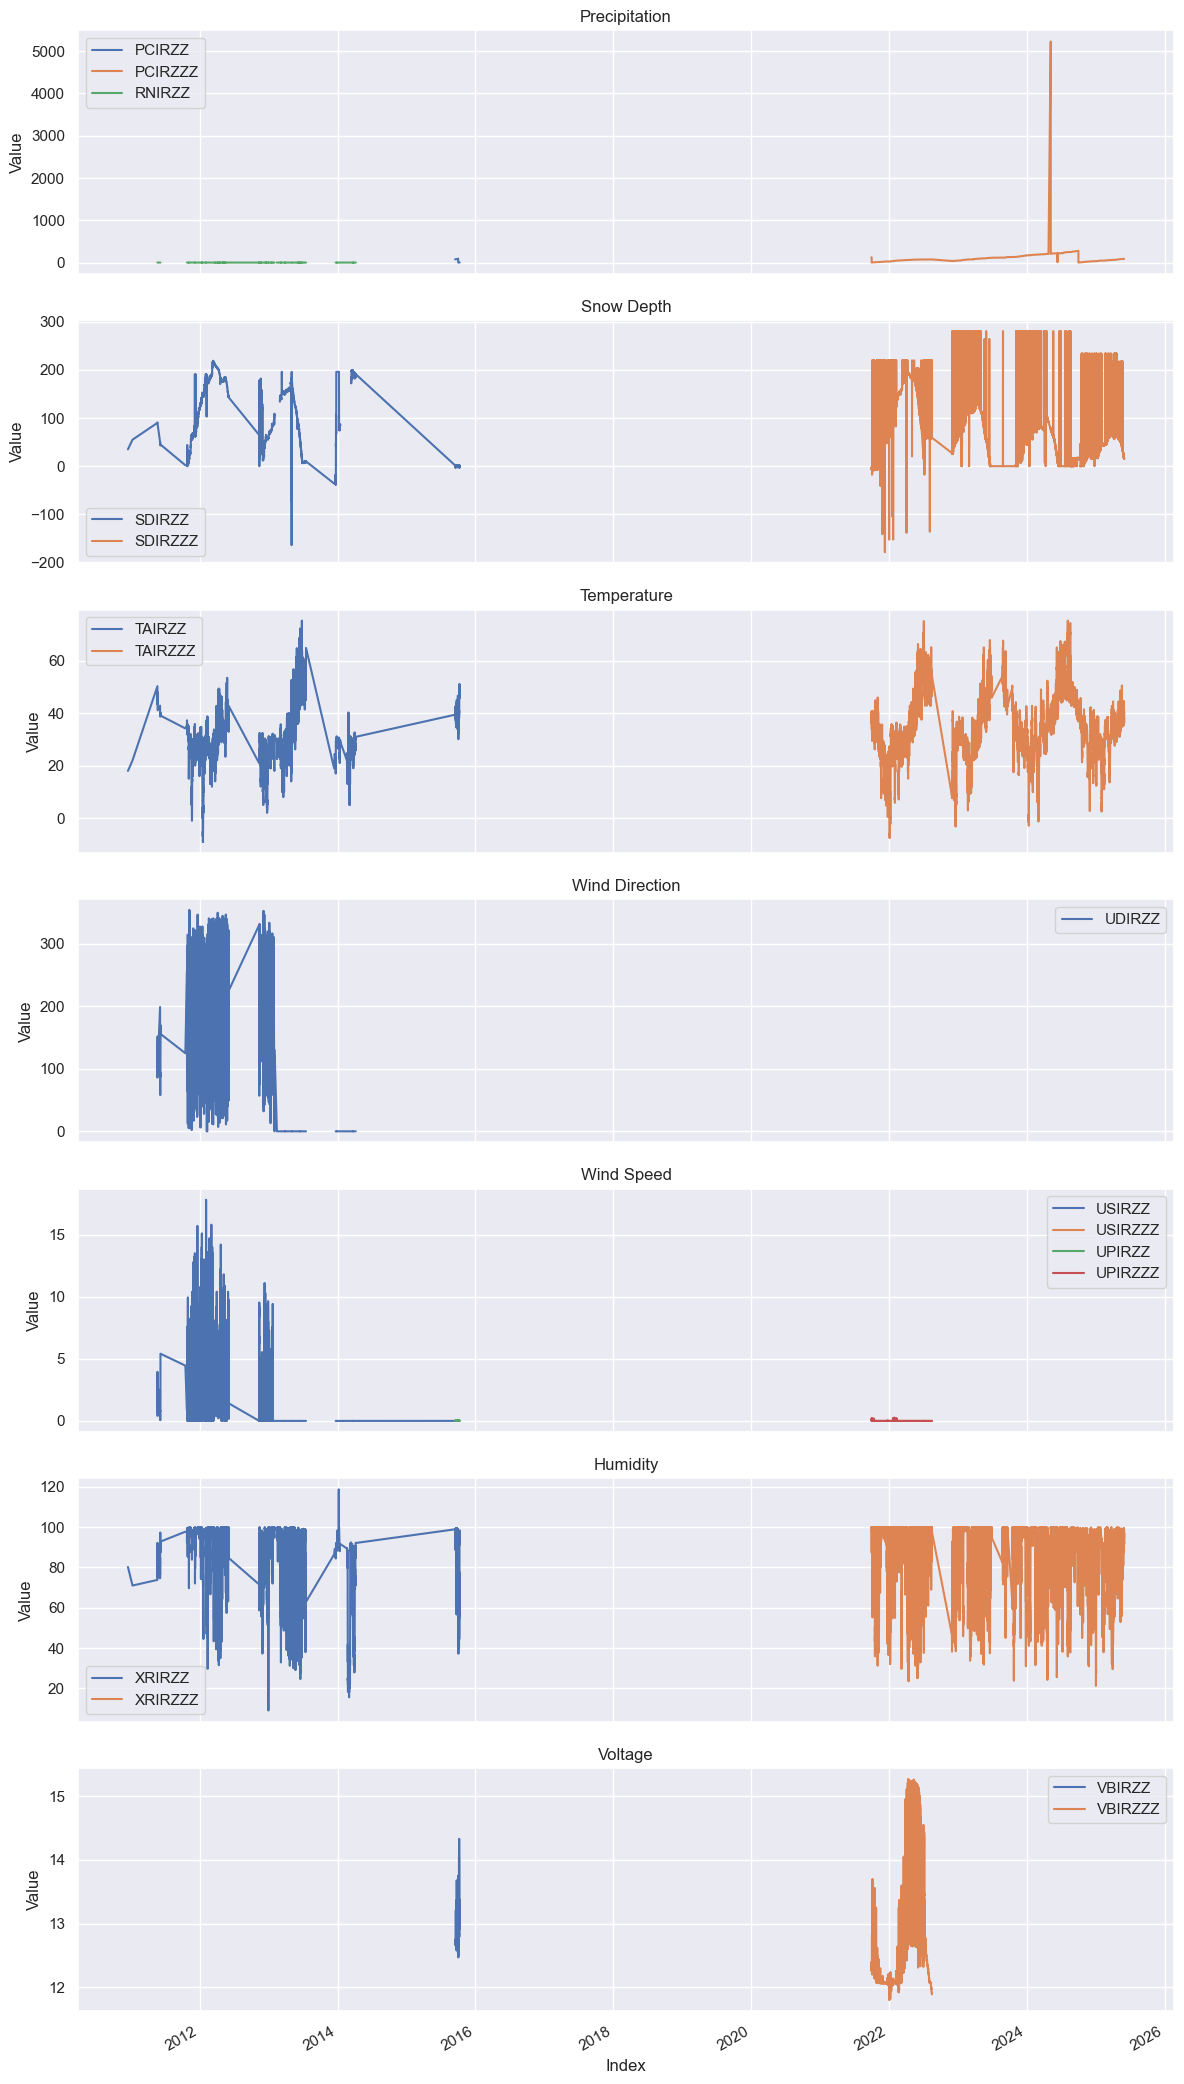

In [11]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df.columns:
            df[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')
plt.tight_layout()
plt.show()

In [35]:
# Remove large outliers by setting them to NaN for each relevant variable
# Adjust thresholds as appropriate for your dataset

df_cleaned = df.copy(deep=True)

# Precipitation
df_cleaned['PCIRZZ'] = df['PCIRZZ'].where((df['PCIRZZ'] < 1000) & (df['PCIRZZ'] > 0), np.nan)
df_cleaned['PCIRZZZ'] = df['PCIRZZZ'].where((df['PCIRZZZ'] < 1000) & (df['PCIRZZZ'] > 0), np.nan)
df_cleaned['RNIRZZ'] = df['RNIRZZ'].where((df['RNIRZZ'] < 1000) & (df['RNIRZZ'] > 0), np.nan)

# Snow Depth
df_cleaned['SDIRZZ'] = df['SDIRZZ'].where((df['SDIRZZ'] < 250) & (df['SDIRZZ'] >= 0), np.nan)
df_cleaned['SDIRZZZ'] = df['SDIRZZZ'].where((df['SDIRZZZ'] < 250) & (df['SDIRZZZ'] >= 0), np.nan)

# Temperature (Fahrenheit, reasonable range -60 to 120)
df_cleaned['TAIRZZ'] = df['TAIRZZ'].where((df['TAIRZZ'] > -60) & (df['TAIRZZ'] < 120), np.nan)
df_cleaned['TAIRZZZ'] = df['TAIRZZZ'].where((df['TAIRZZZ'] > -60) & (df['TAIRZZZ'] < 120), np.nan)

# Wind Direction (0-360)
df_cleaned['UDIRZZ'] = df['UDIRZZ'].where((df['UDIRZZ'] >= 0) & (df['UDIRZZ'] <= 360), np.nan)

# Wind Speed (mph, 0-150)
for col in ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ']:
    df_cleaned[col] = df[col].where((df[col] >= 0) & (df[col] < 150), np.nan)

# Humidity (0-100)
df_cleaned['XRIRZZ'] = df['XRIRZZ'].where((df['XRIRZZ'] >= 0) & (df['XRIRZZ'] <= 100), np.nan)
df_cleaned['XRIRZZZ'] = df['XRIRZZZ'].where((df['XRIRZZZ'] >= 0) & (df['XRIRZZZ'] <= 100), np.nan)

# Voltage (reasonable range, e.g., 0-20)
df_cleaned['VBIRZZ'] = df['VBIRZZ'].where((df['VBIRZZ'] > 0) & (df['VBIRZZ'] < 20), np.nan)
df_cleaned['VBIRZZZ'] = df['VBIRZZZ'].where((df['VBIRZZZ'] > 0) & (df['VBIRZZZ'] < 20), np.nan)

In [37]:
df_cleaned.head()

,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
datetime,,,,,,,,,,,,,,,,,,,
2010-12-15 22:00:00,PPSA2,2010-12-15 22:00:00,NaN,NaN,NaN,35.0,NaN,18.0,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,80.20,NaN
2011-01-09 04:15:00,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,55.0,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.00,NaN
2011-05-21 03:45:00,PPSA2,2011-05-21 03:45:00,NaN,NaN,NaN,90.0,NaN,50.3,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,73.79,NaN
2011-05-21 04:15:00,PPSA2,2011-05-21 04:15:00,NaN,NaN,NaN,90.0,NaN,45.7,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,84.80,NaN
2011-05-21 04:45:00,PPSA2,2011-05-21 04:45:00,NaN,NaN,NaN,90.0,NaN,44.5,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,87.10,NaN


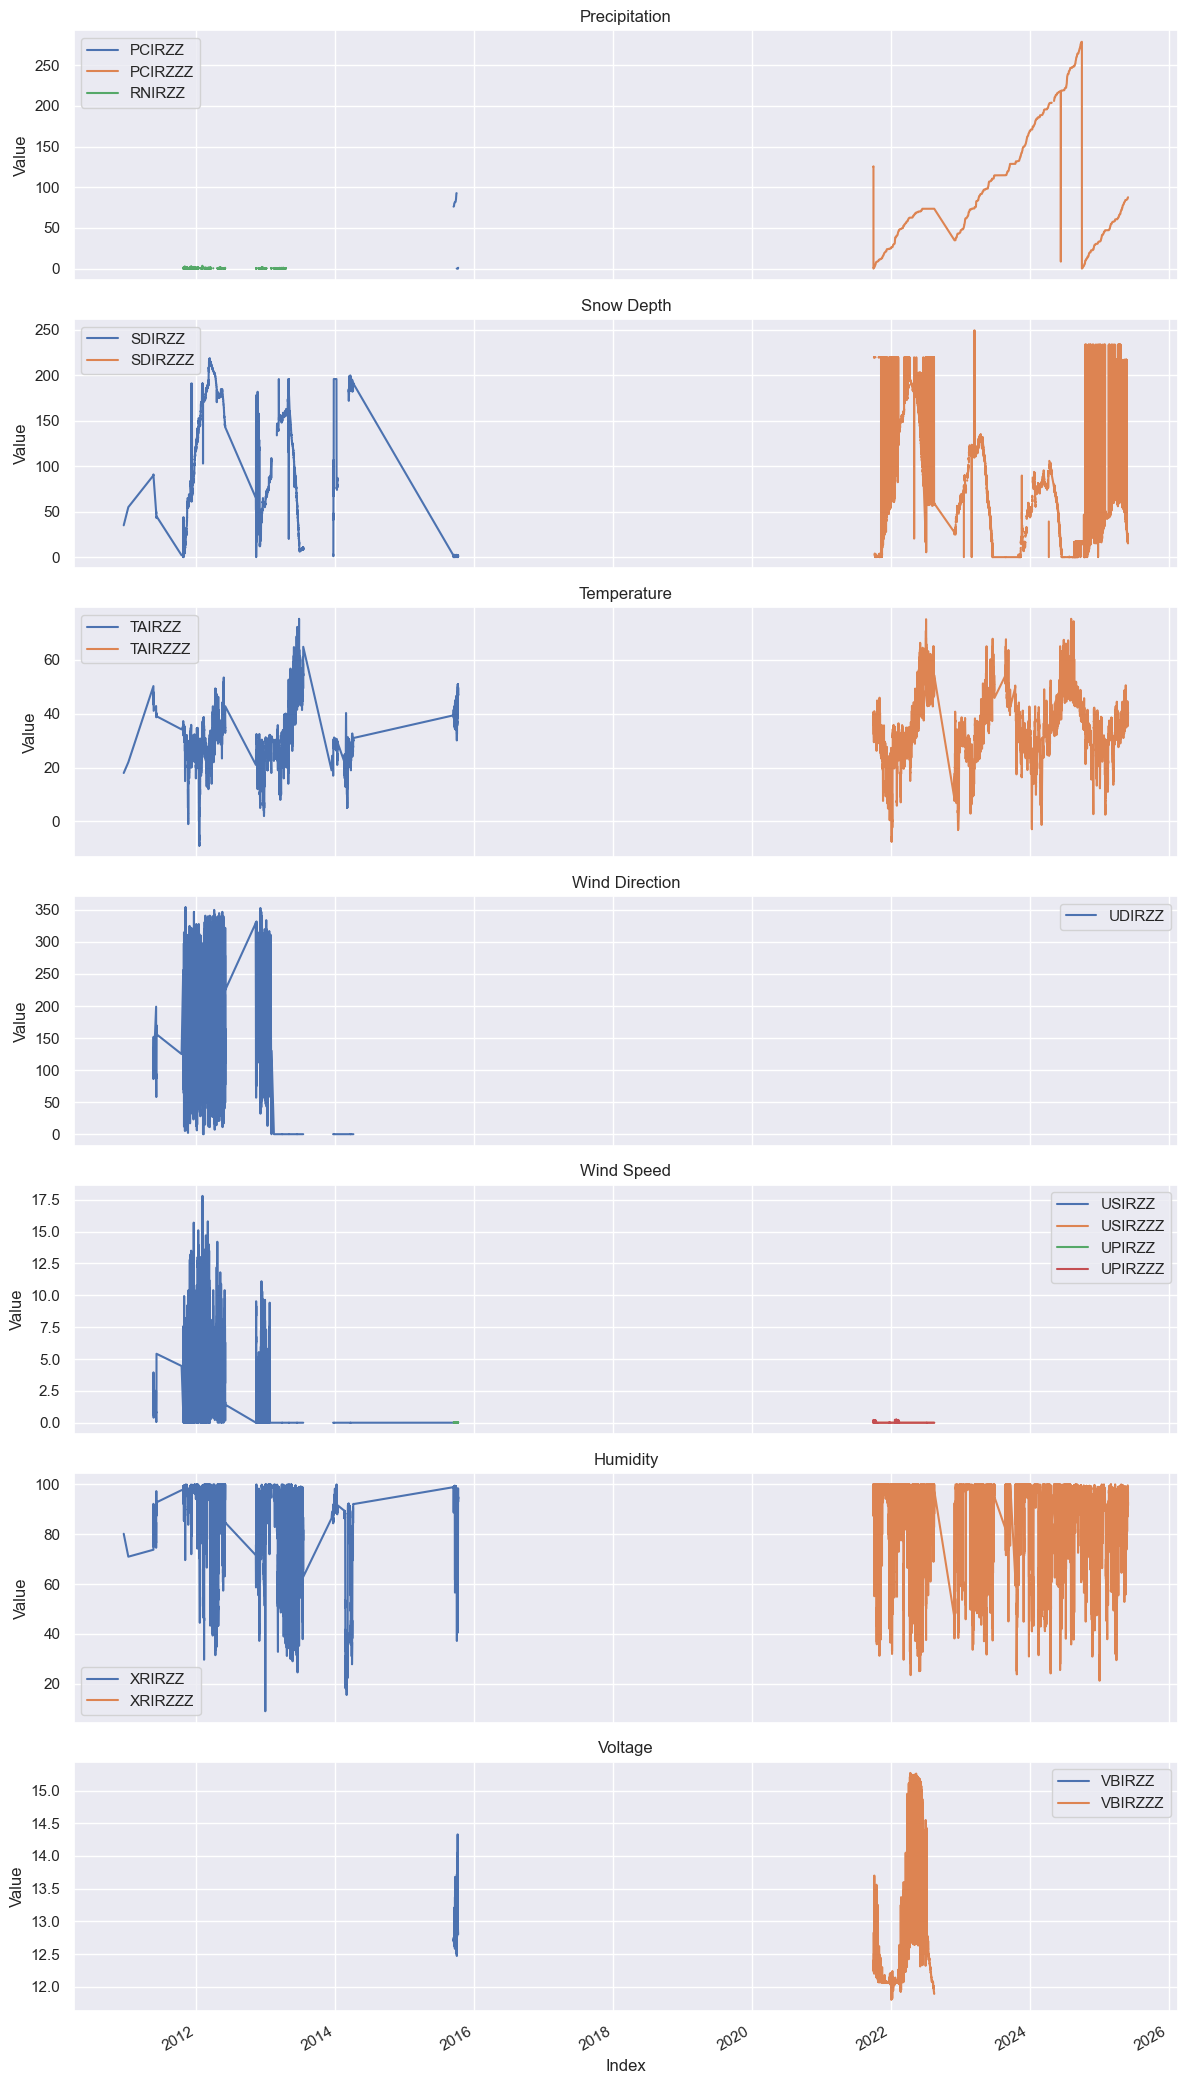

In [36]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df_cleaned.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df_cleaned.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df_cleaned.columns:
            df_cleaned[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')
plt.tight_layout()
plt.show()

In [17]:
import statsmodels.api as sm

In [23]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(numeric_cols)

Index(['PCIRZZ', 'PCIRZZZ', 'RNIRZZ', 'SDIRZZ', 'SDIRZZZ', 'TAIRZZ', 'TAIRZZZ',
       'UDIRZZ', 'UHIRZZZ', 'UPIRZZ', 'UPIRZZZ', 'USIRZZ', 'USIRZZZ', 'VBIRZZ',
       'VBIRZZZ', 'XRIRZZ', 'XRIRZZZ'],
      dtype='object')


In [32]:
# frac = 0.1 
# df_cleaned = sm.nonparametric.lowess(df_cleaned, frac=frac, return_sorted=False)
# df_cleaned

# Set smoothing parameter
frac = 0.01  # Adjust this for more/less smoothing

# Reset index to access 'datetime' as a column
df_smoothed = df_cleaned.reset_index()

# Apply LOWESS smoothing to all numeric columns
# for col in ["PCIRZZZ", "SDIRZZZ", "TAIRZZZ", "XRIRZZZ", "PPIRZZZ"]:
for col in df.select_dtypes(include=[np.number]).columns:
    df_smoothed[col] = sm.nonparametric.lowess(
        df_smoothed[col], df_smoothed["datetime"], frac=frac, return_sorted=False
    )

# Restore datetime as index
df_smoothed.set_index("datetime", inplace=True)

In [24]:
df_smoothed.head()


,station,utc_valid,PCIRZZ,PCIRZZZ,RNIRZZ,SDIRZZ,SDIRZZZ,TAIRZZ,TAIRZZZ,UDIRZZ,UHIRZZZ,UPIRZZ,UPIRZZZ,USIRZZ,USIRZZZ,VBIRZZ,VBIRZZZ,XRIRZZ,XRIRZZZ
datetime,,,,,,,,,,,,,,,,,,,
2010-12-15 22:00:00,PPSA2,2010-12-15 22:00:00,NaN,NaN,NaN,-256.392830,NaN,19.962154,NaN,170.0,NaN,NaN,NaN,1.790,NaN,NaN,NaN,74.257339,NaN
2011-01-09 04:15:00,PPSA2,2011-01-09 04:15:00,NaN,NaN,NaN,-236.558620,NaN,23.530153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.171929,NaN
2011-05-21 03:45:00,PPSA2,2011-05-21 03:45:00,NaN,NaN,NaN,-128.653898,NaN,42.808371,NaN,102.0,NaN,NaN,NaN,0.631,NaN,NaN,NaN,86.755655,NaN
2011-05-21 04:15:00,PPSA2,2011-05-21 04:15:00,NaN,NaN,NaN,-128.636863,NaN,42.808860,NaN,103.0,NaN,NaN,NaN,1.060,NaN,NaN,NaN,86.758470,NaN
2011-05-21 04:45:00,PPSA2,2011-05-21 04:45:00,NaN,NaN,NaN,-128.619829,NaN,42.809338,NaN,110.0,NaN,NaN,NaN,1.270,NaN,NaN,NaN,86.761287,NaN


then, reclean the smoothed data...

In [44]:
# Precipitation
df_smoothed['PCIRZZ'] = df_smoothed['PCIRZZ'].where((df_smoothed['PCIRZZ'] < 1000) & (df_smoothed['PCIRZZ'] > 0), np.nan)
df_smoothed['PCIRZZZ'] = df_smoothed['PCIRZZZ'].where((df_smoothed['PCIRZZZ'] < 1000) & (df_smoothed['PCIRZZZ'] > 0), np.nan)
df_smoothed['RNIRZZ'] = df_smoothed['RNIRZZ'].where((df_smoothed['RNIRZZ'] < 1000) & (df_smoothed['RNIRZZ'] > 0), np.nan)

# Snow Depth
df_smoothed['SDIRZZ'] = df_smoothed['SDIRZZ'].where((df_smoothed['SDIRZZ'] < 250) & (df_smoothed['SDIRZZ'] >= 0), np.nan)
df_smoothed['SDIRZZZ'] = df_smoothed['SDIRZZZ'].where((df_smoothed['SDIRZZZ'] < 250) & (df_smoothed['SDIRZZZ'] >= 0), np.nan)

# Temperature (Fahrenheit, reasonable range -60 to 120)
df_smoothed['TAIRZZ'] = df_smoothed['TAIRZZ'].where((df_smoothed['TAIRZZ'] > -60) & (df_smoothed['TAIRZZ'] < 120), np.nan)
df_smoothed['TAIRZZZ'] = df_smoothed['TAIRZZZ'].where((df_smoothed['TAIRZZZ'] > -60) & (df_smoothed['TAIRZZZ'] < 120), np.nan)

# Wind Direction (0-360)
df_smoothed['UDIRZZ'] = df_smoothed['UDIRZZ'].where((df_smoothed['UDIRZZ'] >= 0) & (df_smoothed['UDIRZZ'] <= 360), np.nan)

# Wind Speed (mph, 0-150)
for col in ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ']:
    df_smoothed[col] = df_smoothed[col].where((df_smoothed[col] >= 0) & (df_smoothed[col] < 150), np.nan)

# Humidity (0-100)
df_smoothed['XRIRZZ'] = df_smoothed['XRIRZZ'].where((df_smoothed['XRIRZZ'] >= 0) & (df_smoothed['XRIRZZ'] <= 100), np.nan)
df_smoothed['XRIRZZZ'] = df_smoothed['XRIRZZZ'].where((df_smoothed['XRIRZZZ'] >= 0) & (df_smoothed['XRIRZZZ'] <= 100), np.nan)

# Voltage (reasonable range, e.g., 0-20)
df_smoothed['VBIRZZ'] = df_smoothed['VBIRZZ'].where((df_smoothed['VBIRZZ'] > 0) & (df_smoothed['VBIRZZ'] < 20), np.nan)
df_smoothed['VBIRZZZ'] = df_smoothed['VBIRZZZ'].where((df_smoothed['VBIRZZZ'] > 0) & (df_smoothed['VBIRZZZ'] < 20), np.nan)

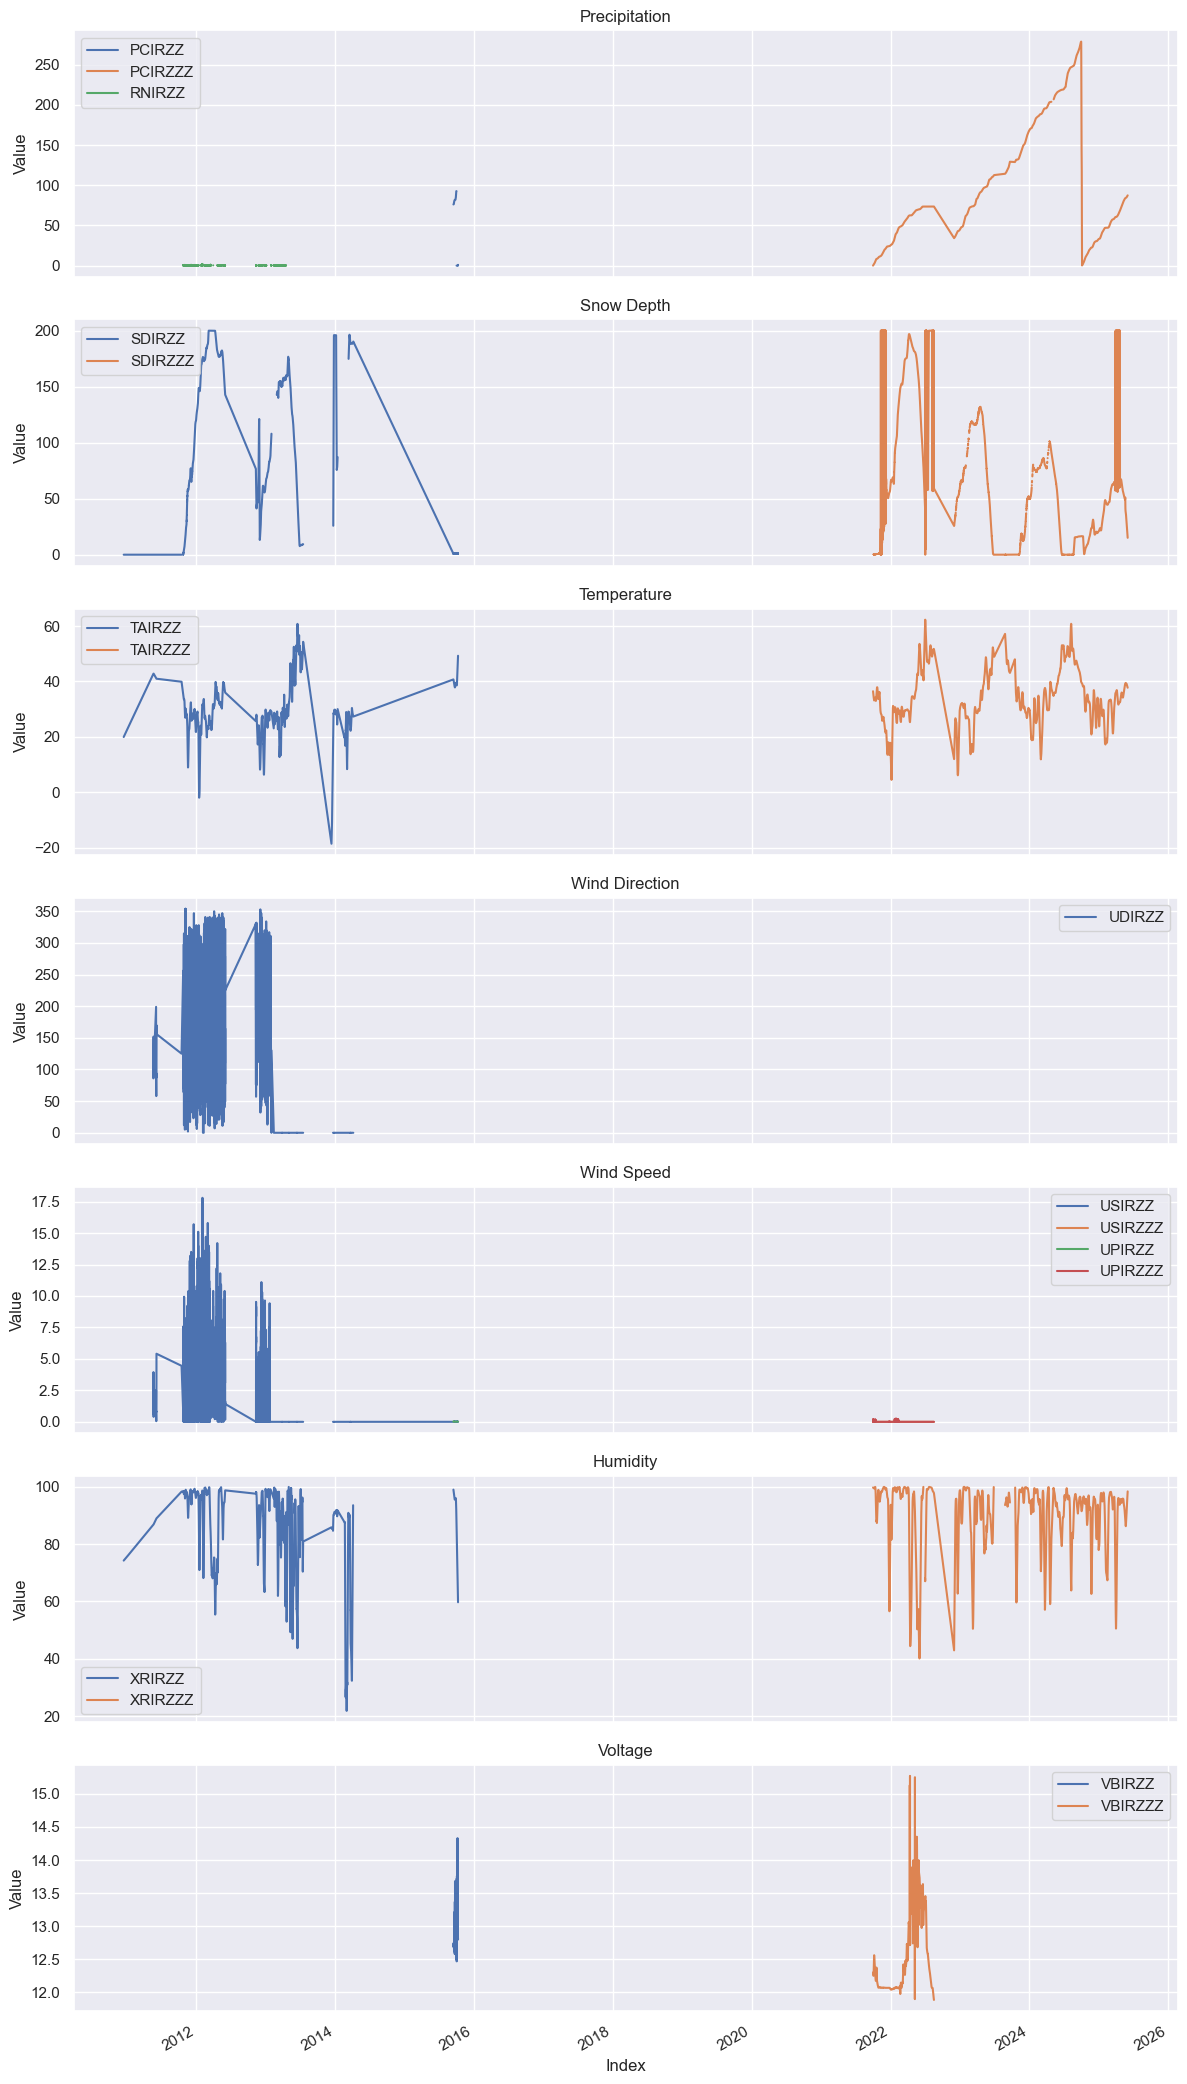

In [45]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df_smoothed.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df_smoothed.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df_smoothed.columns:
            df_smoothed[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')
plt.tight_layout()
plt.show()

In [46]:
# # drop snow depth values in df_smoothed that are less than 0
# df_smoothed['SDIRZZ']  = df_smoothed['SDIRZZ'].clip(lower=0)
# df_smoothed['SDIRZZZ'] = df_smoothed['SDIRZZZ'].clip(lower=0)

# df_smoothed['SDIRZZ']  = df_smoothed['SDIRZZ'].clip(upper=200)
# df_smoothed['SDIRZZZ'] = df_smoothed['SDIRZZZ'].clip(upper=200)

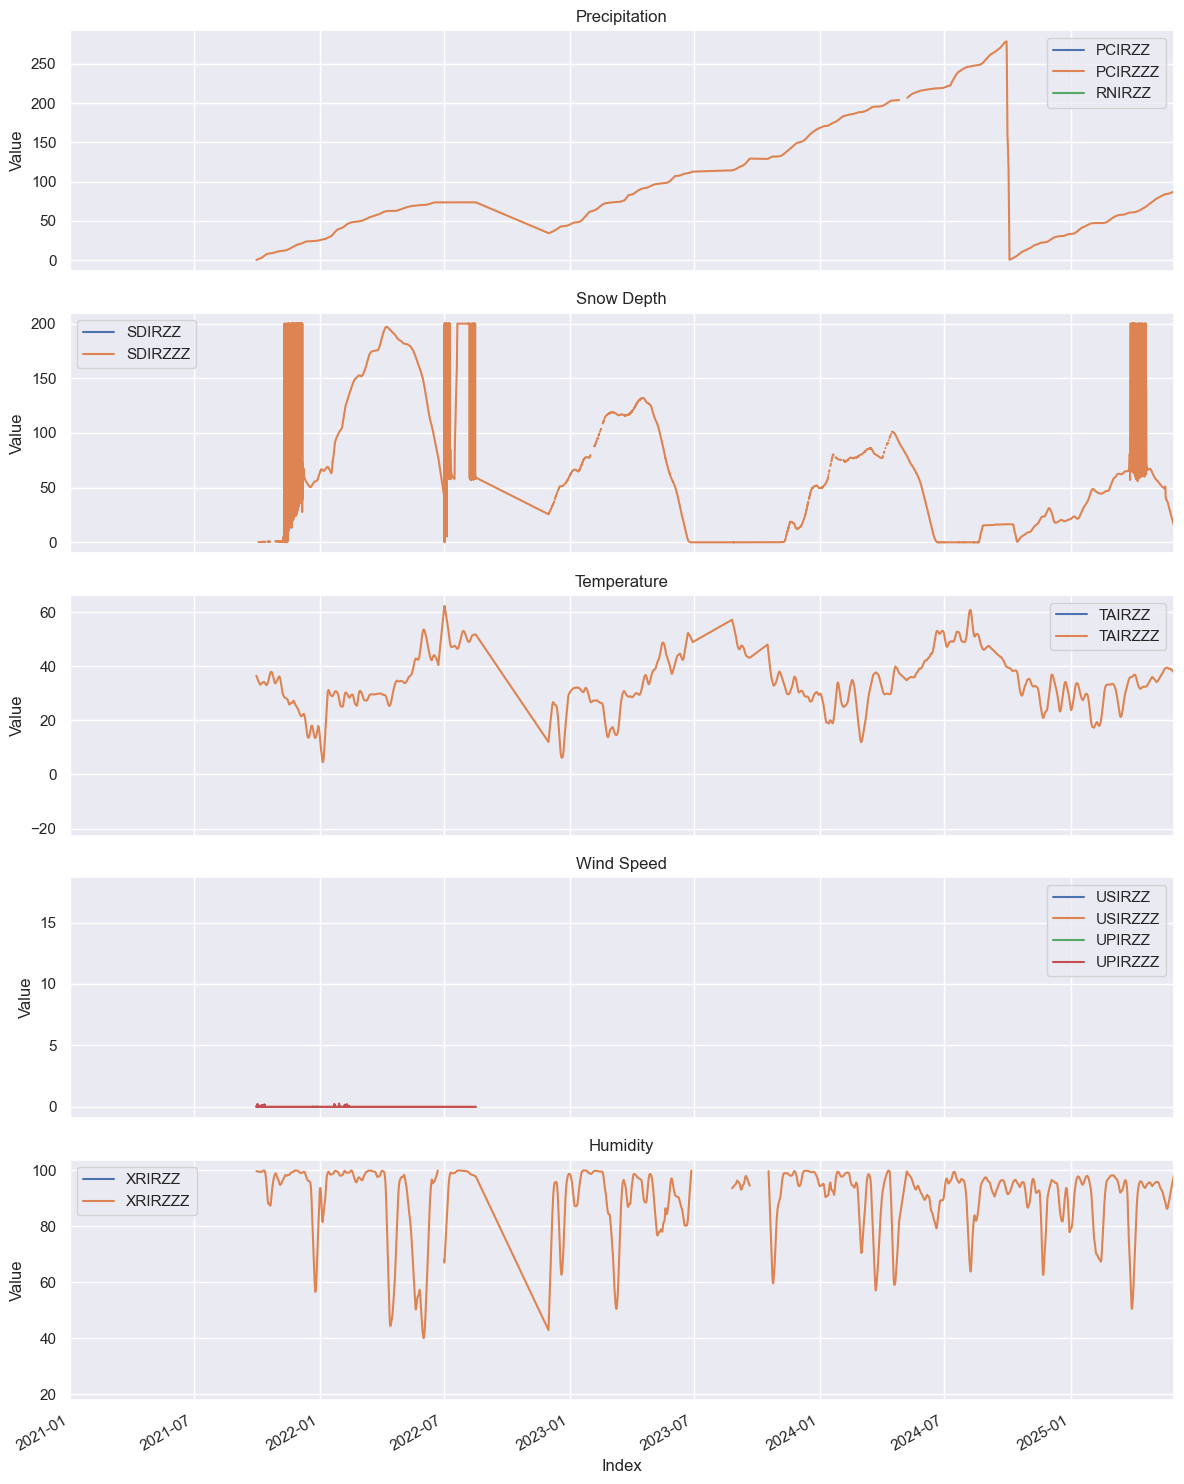

In [48]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    # 'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    # 'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    # 'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df_smoothed.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df_smoothed.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df_smoothed.columns:
            df_smoothed[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')

# zoom into a specific date range
start_date = '2021-01-01'
end_date = '2025-06-01'
xlim = pd.to_datetime([start_date, end_date])
axes[-1].set_xlim(xlim)
# axes[-1].xaxis.set_major_locator(mpl.dates.MonthLocator())
# axes[-1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

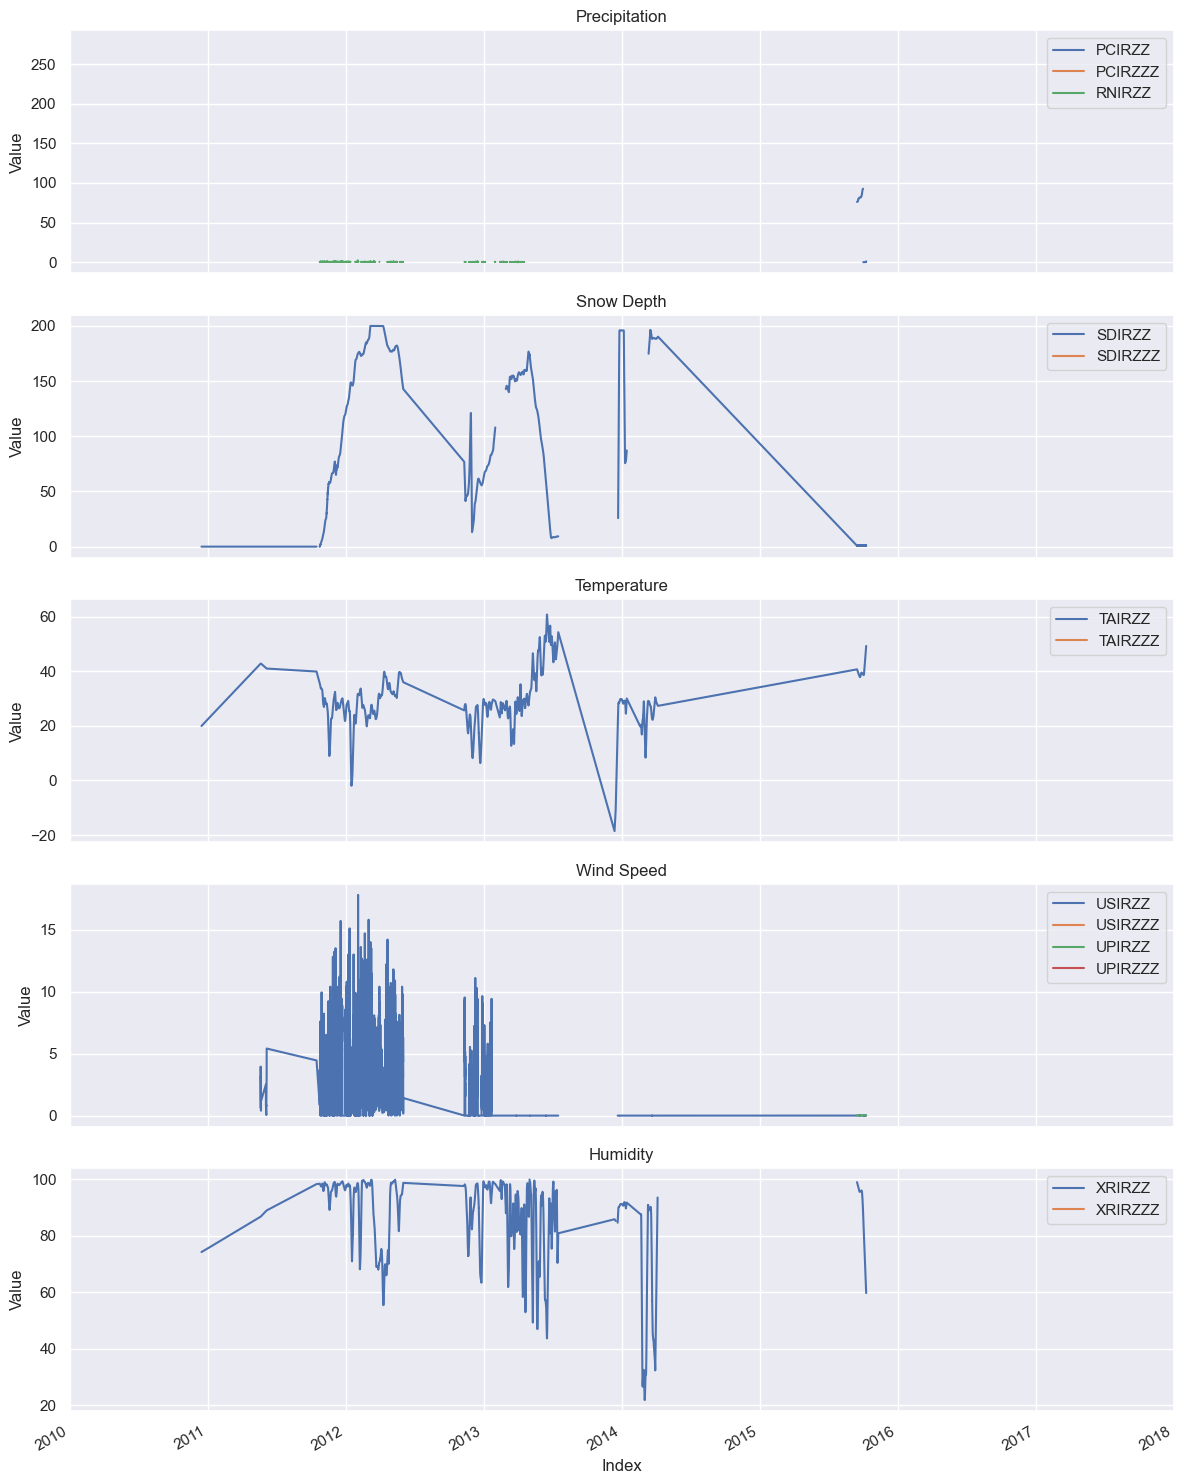

In [49]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    # 'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    # 'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    # 'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df_smoothed.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df_smoothed.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df_smoothed.columns:
            df_smoothed[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')

# zoom into a specific date range
start_date = '2010-01-01'
end_date = '2018-01-01'
xlim = pd.to_datetime([start_date, end_date])
axes[-1].set_xlim(xlim)
# axes[-1].xaxis.set_major_locator(mpl.dates.MonthLocator())
# axes[-1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

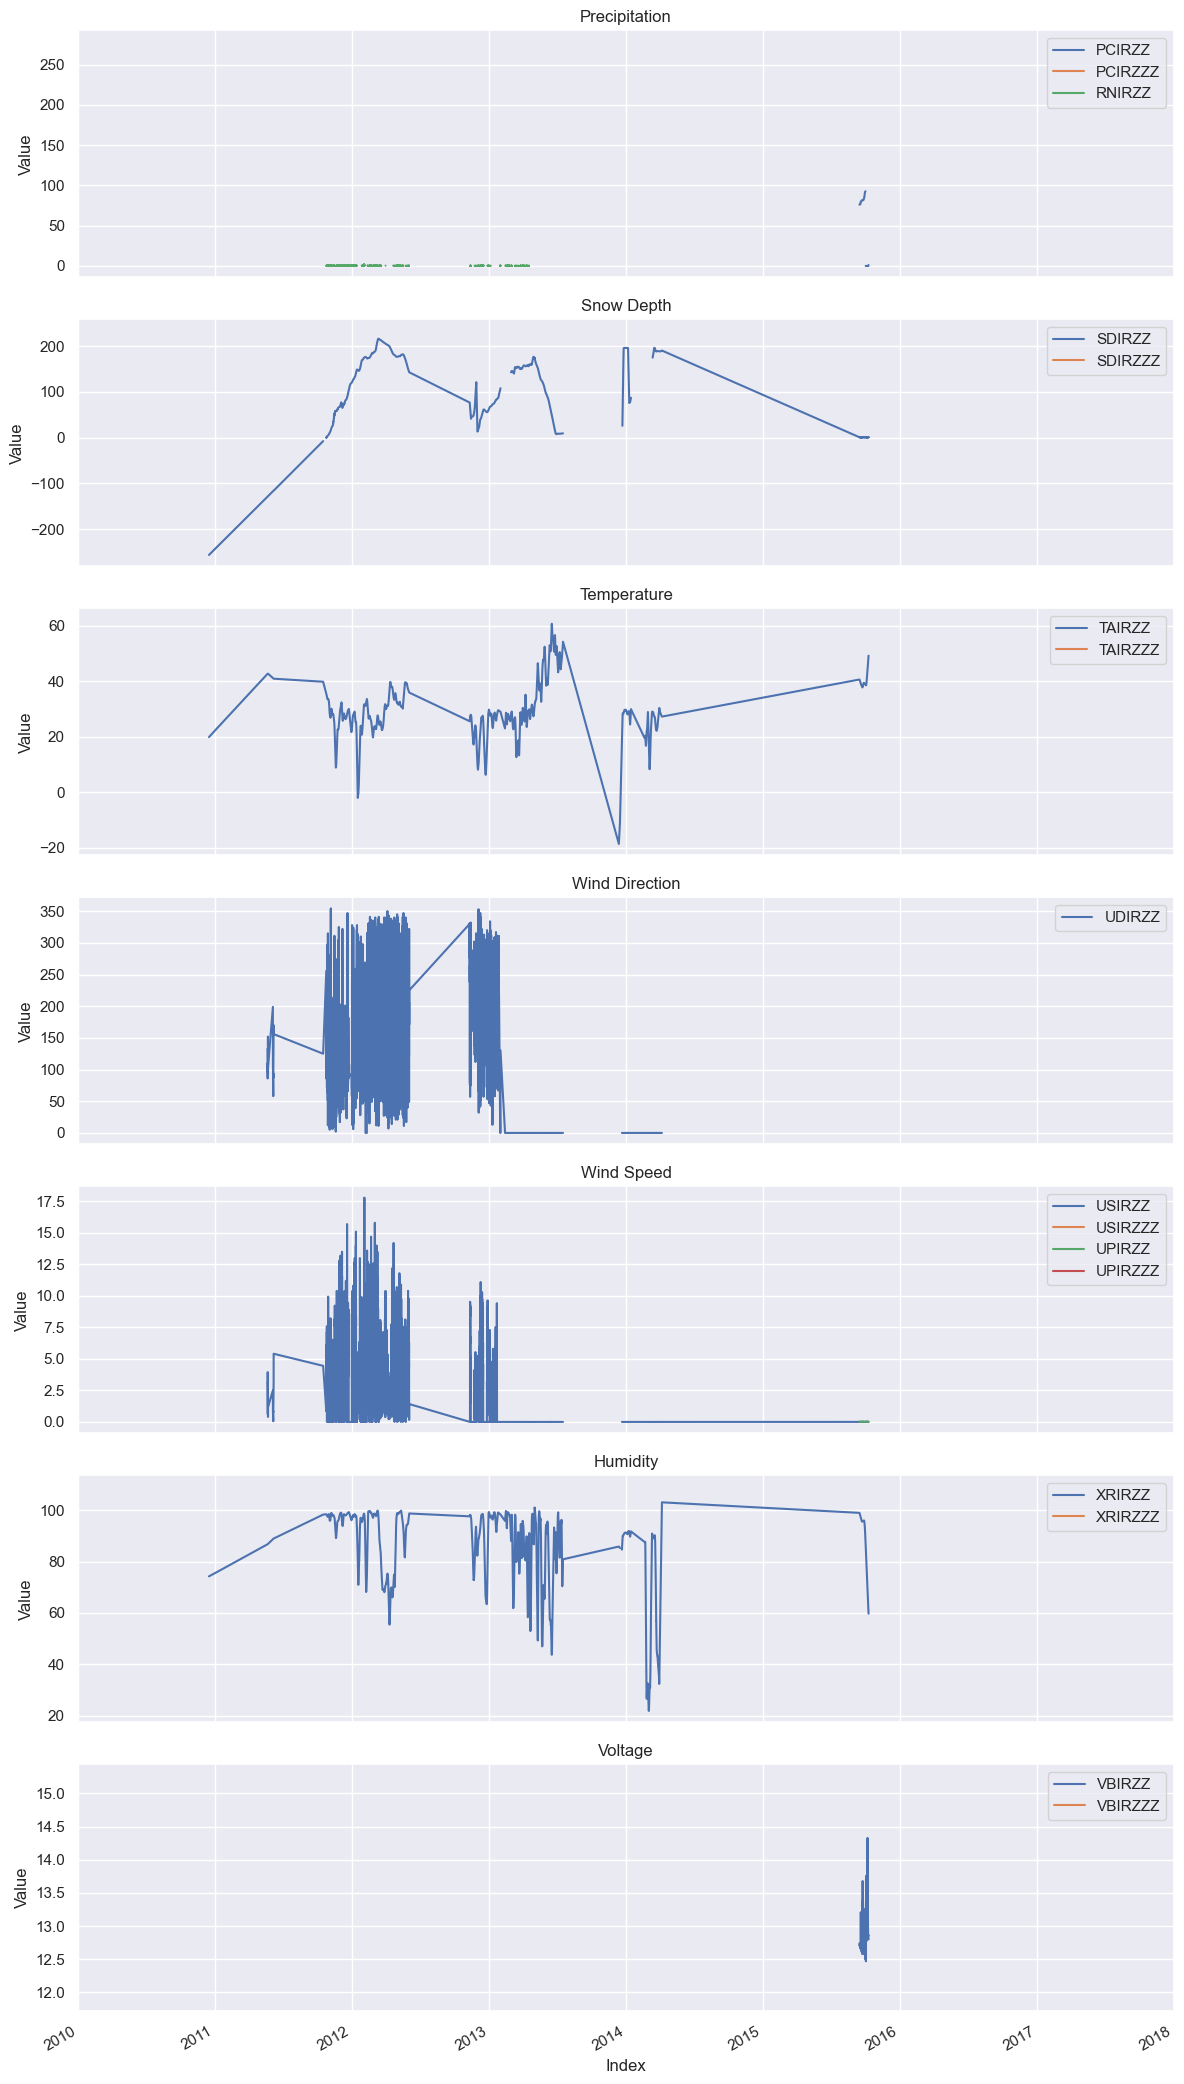

In [29]:
# Group variables by similarity for subplots
variable_groups = {
    'Precipitation': ['PCIRZZ', 'PCIRZZZ', 'RNIRZZ'],
    'Snow Depth': ['SDIRZZ', 'SDIRZZZ'],
    'Temperature': ['TAIRZZ', 'TAIRZZZ'],
    'Wind Direction': ['UDIRZZ'],
    'Wind Speed': ['USIRZZ', 'USIRZZZ', 'UPIRZZ', 'UPIRZZZ'],
    'Humidity': ['XRIRZZ', 'XRIRZZZ'],
    'Voltage': ['VBIRZZ', 'VBIRZZZ'],
    'Other': ['UHİRZZZ'] if 'UHİRZZZ' in df_smoothed.columns else []
}

# Remove empty groups
variable_groups = {k: v for k, v in variable_groups.items() if any(col in df_smoothed.columns for col in v)}

fig, axes = plt.subplots(len(variable_groups), 1, figsize=(12, 3 * len(variable_groups)), sharex=True)

if len(variable_groups) == 1:
    axes = [axes]

for ax, (group, cols) in zip(axes, variable_groups.items()):
    for col in cols:
        if col in df_smoothed.columns:
            df_smoothed[col].plot(ax=ax, label=col)
    ax.set_title(group)
    ax.legend()
    ax.set_ylabel('Value')

axes[-1].set_xlabel('Index')

# zoom into a specific date range
start_date = '2010-01-01'
end_date = '2018-01-01'
xlim = pd.to_datetime([start_date, end_date])
axes[-1].set_xlim(xlim)
# axes[-1].xaxis.set_major_locator(mpl.dates.MonthLocator())
# axes[-1].xaxis.set_major_formatter(mpl.dates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [ ]:
# # Plot each variable in df (excluding 'station' and 'utc_valid') in its own subplot
# data_columns = [col for col in df.columns if col not in ['station', 'utc_valid']]
# n_vars = len(data_columns)

# fig, axes = plt.subplots(n_vars, 1, figsize=(12, 3 * n_vars), sharex=True)

# if n_vars == 1:
#     axes = [axes]

# for ax, col in zip(axes, data_columns):
#     df[col].plot(ax=ax)
#     ax.set_title(col)
#     ax.set_ylabel('Value')

# axes[-1].set_xlabel('datetime')
# plt.tight_layout()
# plt.show()